# EfficientNetV2-S for Diabetic Foot Ulcer (DFU) Classification

This notebook implements **EfficientNetV2-S** with ImageNet transfer learning for DFU severity classification using **5-Fold Stratified Cross-Validation**.  
Optimised for **Kaggle GPU** execution.

---

### Training Configuration

| Parameter | Value |
|---|---|
| Optimizer | Adam (lr = 1e-3, weight_decay = 1e-4) |
| LR Scheduler | ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7) |
| Early Stopping | patience = 7 (monitors val_loss) |
| Loss Function | CrossEntropyLoss with balanced class weights |
| Batch Size | 32 |
| Max Epochs | 30 per fold |

### Data Augmentation

| Transform | Value |
|---|---|
| Horizontal Flip | p = 0.5 |
| Vertical Flip | p = 0.5 |
| Rotation | ±20° |
| Zoom | ±20% |
| Brightness | ±10% |
| Contrast | ±10% |

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# KAGGLE SETUP — Clone repo & install dependencies
# Run this cell FIRST on Kaggle to pull the project code and utilities.
# ══════════════════════════════════════════════════════════════════════════════
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/kaggle/working/KHOTAA'
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

# Clone the repo (skip if already cloned)
if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f"✓ Cloned {BRANCH} branch → {REPO_DIR}")
else:
    print(f"✓ Repo already exists at {REPO_DIR}")

# Change into the notebook's expected working directory
os.chdir(WORKING_DIR)
print(f"✓ Working directory: {os.getcwd()}")

# Install additional dependencies
!pip install roboflow -q
print("✓ Kaggle setup complete")

Cloning into '/kaggle/working/KHOTAA'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 583 (delta 32), reused 36 (delta 25), pack-reused 535 (from 1)
Receiving objects: 100% (583/583), 20.83 MiB | 32.51 MiB/s, done.
Resolving deltas: 100% (277/277), done.
✓ Cloned new-start branch → /kaggle/working/KHOTAA
✓ Working directory: /kaggle/working/KHOTAA/models/classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.7 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavi

## 1. Imports & Configuration

In [2]:
# ── Standard Library ──────────────────────────────────────────────────────────────
import sys
import os
import random
import warnings
import json
warnings.filterwarnings('ignore')

# ── Numerical & Visualization ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── PyTorch ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from PIL import Image

# ── Scikit-learn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime
import copy

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Project imports ─────────────────────────────────────────────────────────────
# Works both locally (../utils) and on Kaggle (cloned repo structure)
sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import training_engine
importlib.reload(training_engine)
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history
)

# ── Hyperparameters & Paths ───────────────────────────────────────────────
IMAGE_SIZE       = (224, 224)
BATCH_SIZE       = 32
EPOCHS           = 30
LEARNING_RATE    = 1e-3
FINE_TUNE_LR     = 1e-5
N_FOLDS          = 5

# ── Roboflow Dataset ────────────────────────────────────────────────────────────
from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

# ── Directories ─────────────────────────────────────────────────────────────────
MODEL_NAME       = 'EfficientNetV2S'
RESULTS_DIR      = 'results'

print("✓ Imports complete (modules reloaded)")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Image size      : {IMAGE_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Dataset path    : {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DFU-1 in folder:: 100%|██████████| 4462/4462 [00:00<00:00, 12420.12it/s]

✓ Imports complete (modules reloaded)
PyTorch version : 2.9.0+cu126
CUDA available  : True
Image size      : (224, 224)
Batch size      : 32
Dataset path    : /kaggle/working/KHOTAA/models/classification/DFU-1/


## 2. Load & Explore Dataset

In [3]:
# ── Verify dataset directory structure ──────────────────────────────────────────
print('Dataset root contents:')
for entry in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, entry)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {entry}')

# ── Load dataset (auto-detects train/valid/val/test splits) ──────────────
loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# ── Print full structure overview ────────────────────────────────────────────────
loader.print_structure()

# ── Initialize preprocessing ───────────────────────────────────────────────────
preprocessor = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# ── PyTorch Dataset class ───────────────────────────────────────────────────────
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── Prepare data for cross-validation (train + valid combined) ────────────
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# ── Initialize 5-fold stratified cross-validation ────────────────────
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print("✓ Dataset loaded and ready for 5-fold cross-validation")

Dataset root contents:
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']

Classes: ['Both', 'Infection', 'Ischaemia', 'None']
Number of classes: 4

Dataset root: /kaggle/working/KHOTAA/models/classification/DFU-1
  [FILE] README.roboflow.txt
  [DIR] test
  [DIR] train
  [DIR] valid

[DatasetLoader] Split 'train': 3112 images
  Split 'train' (3112 images):
    Both: 323  (10.4%)
    Infection: 1327  (42.6%)
    Ischaemia: 111  (3.6%)
    None: 1351  (43.4%)
[DatasetLoader] Split 'valid': 889 images
  Split 'valid' (889 images):
    Both: 93  (10.5%)
    Infection: 381  (42.9%)
    Ischaemia: 41  (4.6%)
    None: 374  (42.1%)
[DatasetLoader] Split 'test': 445 images
  Split 'test' (445 images):
    Both: 45  (10.1%)
    Infection: 193  (43.4%)
    Ischaemia: 15  (3.4%)
    No

[DatasetLoader] Split 'train': 3112 images


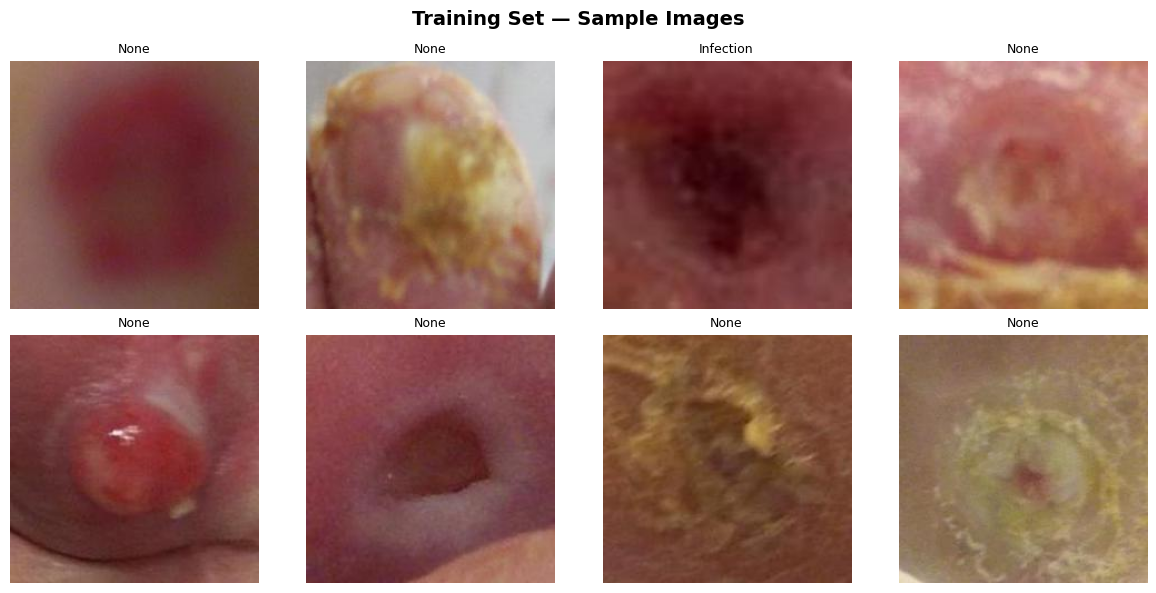

In [4]:
# ── Display sample images from training set ─────────────────────────────────
loader.show_samples('train', n_cols=4, n_rows=2, title='Training Set — Sample Images')

[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
[DatasetLoader] Split 'test': 445 images


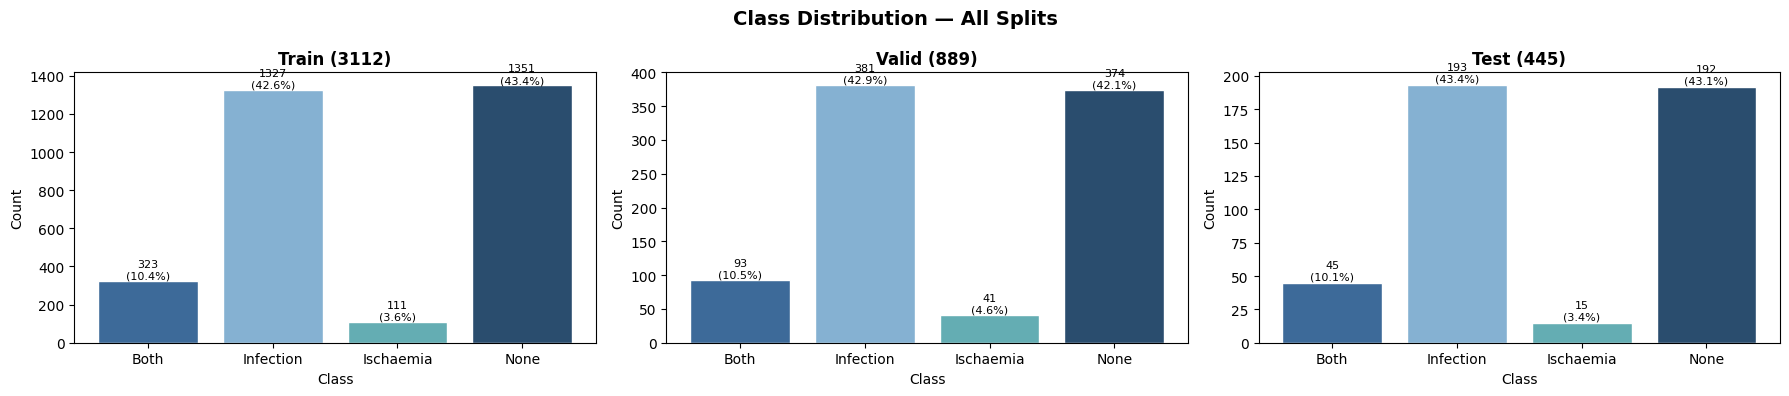

Total training+val samples: 4001
Class counts: {'Both': 416, 'Infection': 1708, 'Ischaemia': 152, 'None': 1725}


In [5]:
import matplotlib.pyplot as plt

PALETTE = ["#3D6A99", "#85B1D2", "#64ADB3", "#2A4D6E"]

# Override plt.show to intercept the figure before it's displayed
original_show = plt.show

def custom_show():
    fig = plt.gcf()
    for ax in fig.axes:
        for i, bar in enumerate(ax.patches):
            bar.set_facecolor(PALETTE[i % len(PALETTE)])
            bar.set_edgecolor('white')
    original_show()

plt.show = custom_show

# Now call — the colors will be applied before display
loader.plot_all_splits_distribution()

# Restore
plt.show = original_show

print(f"Total training+val samples: {len(y_all)}")
print(f"Class counts: { {classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)} }")

## 3. Data Preprocessing & Augmentation Visualization

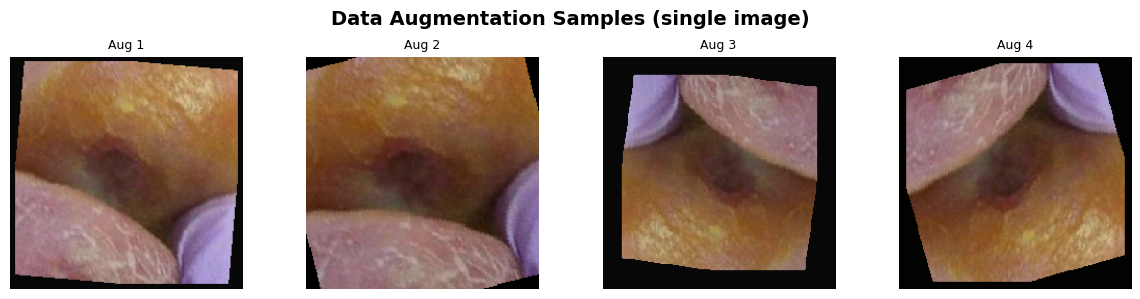

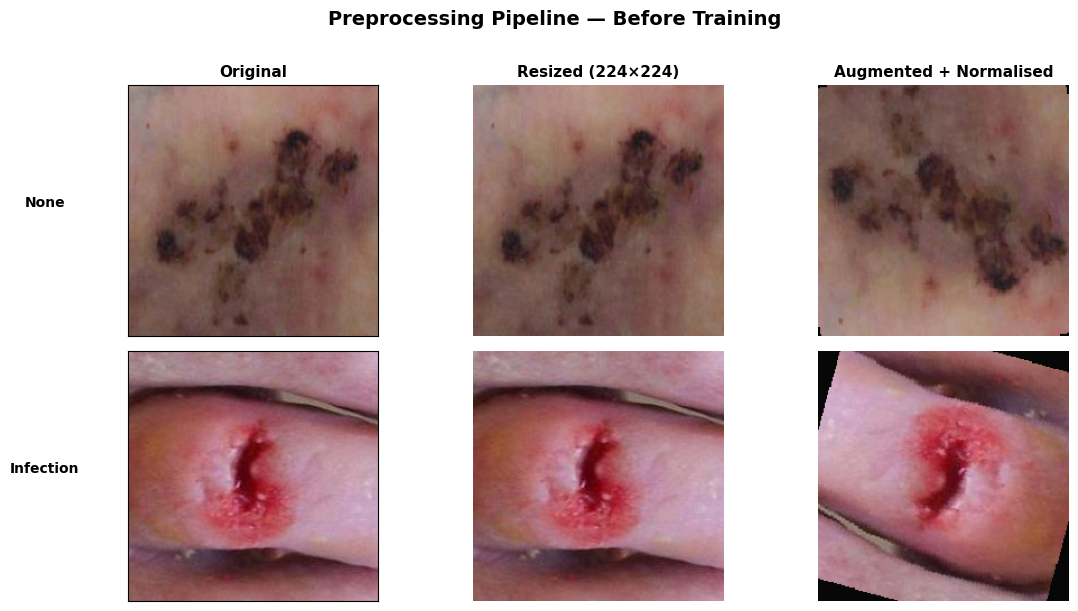

Note: PyTorch applies augmentation on-the-fly during training,
so class counts remain the same. Augmentation adds visual variety, not extra samples.


In [6]:
# ── Visualise augmentation on a single image ──────────────────────────────────
sample_path = X_train[0]
preprocessor.show_augmentation_samples(
    sample_path, n_samples=4,
    title='Data Augmentation Samples (single image)'
)

# ── Preprocessing sample results: Original → Resized → Augmented+Normalised ──
preprocessor.show_preprocessing_samples(
    X_train, y_train, classes,
    n_samples=2,
    title='Preprocessing Pipeline — Before Training'
)

print("Note: PyTorch applies augmentation on-the-fly during training,")
print("so class counts remain the same. Augmentation adds visual variety, not extra samples.")

## 4. Build Model (Transfer Learning)

In [7]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Create EfficientNetV2-S model ────────────────────────────────────────────────
def create_efficientnetv2s_model(num_classes=4, pretrained=True):
    """
    Create EfficientNetV2-S model for DFU classification.
    Uses ImageNet pretrained weights with custom classification head.
    
    Architecture:
        EfficientNetV2-S backbone (frozen or trainable)
        → AdaptiveAvgPool2d → Flatten
        → Dropout(0.2)
        → Linear(1280 → num_classes)
    
    Args:
        num_classes: Number of output classes
        pretrained: Use ImageNet pretrained weights
    
    Returns:
        EfficientNetV2-S model configured for DFU classification
    """
    if pretrained:
        model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    else:
        model = models.efficientnet_v2_s(weights=None)
    
    # Replace final classifier layer: Linear(1280 → num_classes)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    
    return model

# ── Test model creation ─────────────────────────────────────────────────────────
test_model = create_efficientnetv2s_model(num_classes=num_classes)
total_params     = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"\n✓ EfficientNetV2-S model created")
print(f"Input size       : 224×224")
print(f"Output classes   : {num_classes}")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Classifier       : {test_model.classifier}")
del test_model  # free memory

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 157MB/s] 



✓ EfficientNetV2-S model created
Input size       : 224×224
Output classes   : 4
Total params     : 20,182,612
Trainable params : 20,182,612
Classifier       : Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


## 5. Class Weights

Compute balanced class weights to handle class imbalance.

In [8]:
# ── Compute balanced class weights  ─────────────
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)

# ── Create weighted loss function ─────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"\n✓ CrossEntropyLoss with balanced class weights")
print(f"  Weights: {class_weights_tensor.cpu().numpy()}")
print(f"  Classes: {classes}")

[ClassWeights] Balanced class weights: {0: 2.4044471153846154, 1: 0.5856264637002342, 2: 6.5805921052631575, 3: 0.5798550724637681}

✓ CrossEntropyLoss with balanced class weights
  Weights: [2.404447  0.5856265 6.580592  0.5798551]
  Classes: ['Both', 'Infection', 'Ischaemia', 'None']


## 6. Training (5-Fold Cross-Validation)

Each fold trains a fresh **EfficientNetV2-S** model from ImageNet-pretrained weights.  
Best model weights per fold are stored **in memory** (no checkpoint files required).

| Component | Setting |
|---|---|
| Optimizer | Adam (lr=1e-3, weight_decay=1e-4) |
| Scheduler | ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7) |
| Epochs | 30 max per fold |
| Early Stopping | patience=7, monitors val_loss |
| Loss | CrossEntropyLoss (balanced class weights) |

In [9]:
# ── 5-Fold Cross-Validation Training ──────────────────────────────────────────
fold_results = []
best_model_state = None       # Best model weights across ALL folds (in memory)
best_overall_acc = 0.0
fold_model_states = {}        # Per-fold best model weights (for aggregated CM)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/{N_FOLDS}\n{'='*60}")
    
    # Prepare fold data
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold   = X_all[val_idx]
    y_val_fold   = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Create fresh model for this fold
    model = create_efficientnetv2s_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer: Adam with lr=1e-3
    optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
    
    # Setup scheduler: ReduceLROnPlateau
    scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                 gamma=0.3, patience=3, min_lr=1e-7)
    
    # Training engine (no checkpoint manager)
    engine = TrainingEngine(model=model, device=device)
    
    # Track best model state for this fold IN the training loop
    fold_best_state = None
    fold_best_acc = 0.0
    
    # Custom training loop to capture best model state in memory
    from utils.training_engine import EarlyStopping
    early_stopper = EarlyStopping(patience=7, verbose=True)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'stopped_epoch': EPOCHS
    }
    
    for epoch in range(EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"{'='*60}")
        
        # Train
        train_loss, train_acc = engine.train_epoch(train_loader, criterion, optimizer)
        
        # Validate
        val_loss, val_acc, _, _, _ = engine.evaluate(val_loader, criterion, measure_inference_time=False)
        
        # Update learning rate
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate: {current_lr:.6f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch results
        print(f"\nEpoch {epoch+1} Results:")
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
        
        # Save best model state IN MEMORY
        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            fold_best_state = copy.deepcopy(model.state_dict())
            print(f"   ✓ New best model! Val Acc: {val_acc*100:.2f}%")
        
        # Check early stopping
        if early_stopper(val_loss, epoch+1):
            history['stopped_epoch'] = epoch + 1
            print(f"\n{'='*60}")
            print(f"Training stopped early at epoch {epoch+1}/{EPOCHS}")
            print(f"Best Validation Accuracy: {fold_best_acc*100:.2f}%")
            print(f"{'='*60}\n")
            break
    else:
        history['stopped_epoch'] = EPOCHS
        print(f"\n{'='*60}")
        print(f"Training Complete! All {EPOCHS} epochs")
        print(f"Best Validation Accuracy: {fold_best_acc*100:.2f}%")
        print(f"{'='*60}\n")
    
    # Store best model state for this fold
    fold_model_states[fold] = fold_best_state
    
    # Track overall best model across all folds
    if fold_best_acc > best_overall_acc:
        best_overall_acc = fold_best_acc
        best_model_state = copy.deepcopy(fold_best_state)
    
    # Store results
    best_val_acc = fold_best_acc
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} — Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# ── Cross-validation summary ───────────────────────────────────────────────────
avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
std_acc    = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% \u00b1 {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07
Training on: cuda

Epoch 1/30


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.97it/s, loss=0.5411, acc=58.18%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.0486 | Train Acc: 53.75%
   Val Loss:   1.0144 | Val Acc:   58.18%
   ✓ New best model! Val Acc: 58.18%

Epoch 2/30


Evaluating: 100%|██████████| 26/26 [00:03<00:00,  7.62it/s, loss=0.5857, acc=59.93%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 0.9064 | Train Acc: 62.12%
   Val Loss:   0.9095 | Val Acc:   59.93%
   ✓ New best model! Val Acc: 59.93%

Epoch 3/30


...

Learning Rate: 0.000300

Epoch 28 Results:
   Train Loss: 0.3373 | Train Acc: 82.85%
   Val Loss:   0.4764 | Val Acc:   77.25%

Epoch 29/30


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.45it/s, loss=0.4636, acc=78.12%]


Learning Rate: 0.000090

Epoch 29 Results:
   Train Loss: 0.3164 | Train Acc: 82.35%
   Val Loss:   0.4270 | Val Acc:   78.12%
   ✓ New best model! Val Acc: 78.12%

Epoch 30/30


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.39it/s, loss=0.4935, acc=78.62%]

Learning Rate: 0.000090

Epoch 30 Results:
   Train Loss: 0.2639 | Train Acc: 85.25%
   Val Loss:   0.4231 | Val Acc:   78.62%
   ✓ New best model! Val Acc: 78.62%

Training Complete! All 30 epochs
Best Validation Accuracy: 78.62%

Fold 5 — Best Acc: 78.62% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 80.81% ± 1.72%
Average Epochs: 29.2

Individual Fold Results:
  Fold 1: 79.28% (epoch 27)
  Fold 2: 83.38% (epoch 30)
  Fold 3: 80.88% (epoch 30)
  Fold 4: 81.88% (epoch 29)
  Fold 5: 78.62% (epoch 30)


## 7. Training Curves & Evaluation Plots

✓ Results directory: /kaggle/working/KHOTAA/models/classification/results/efficientnetv2s
✓ Best fold: 2 (83.38%)
✓ Loaded best model from MEMORY


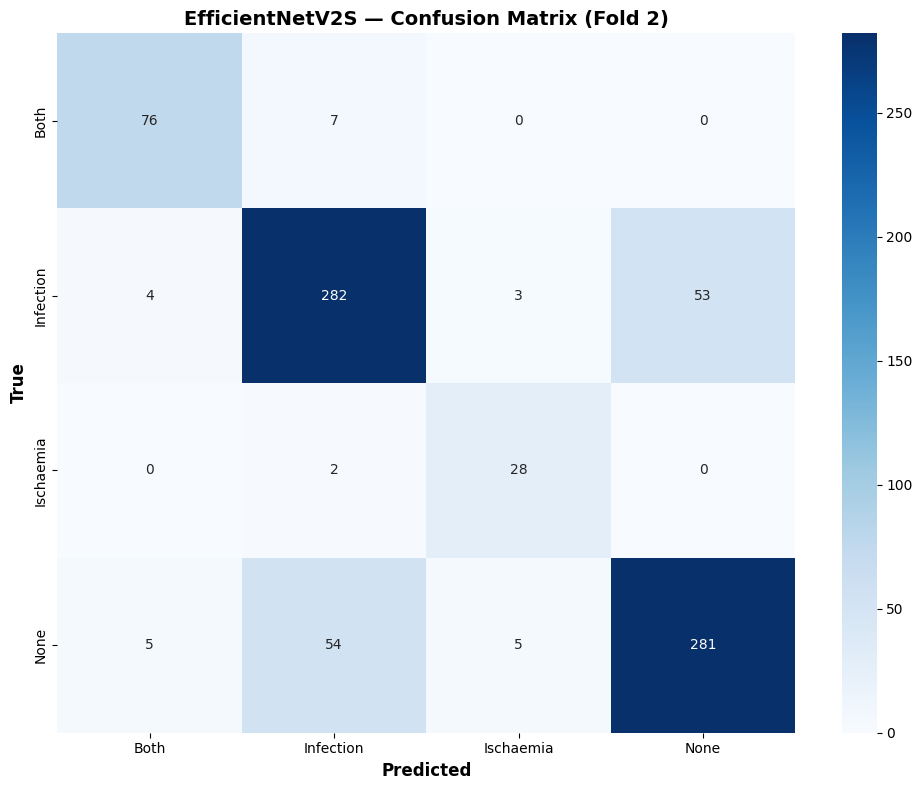


⏳ Generating aggregated confusion matrix across all folds...
  ✓ Fold 1 processed
  ✓ Fold 2 processed
  ✓ Fold 3 processed
  ✓ Fold 4 processed
  ✓ Fold 5 processed


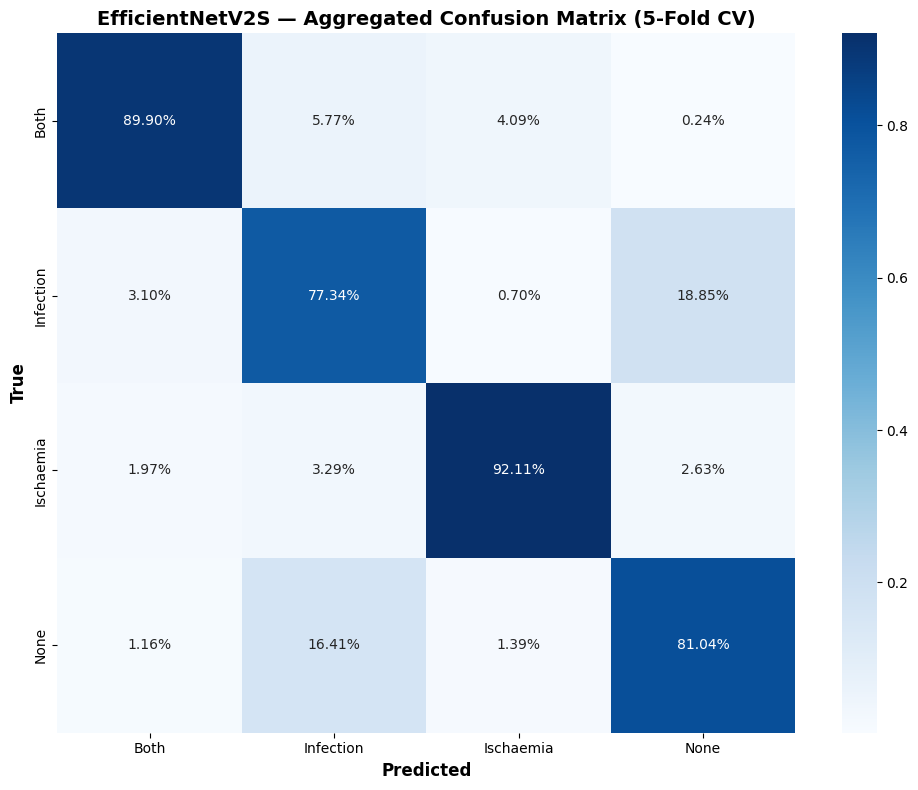

✓ Aggregated CM saved (4001 total predictions)


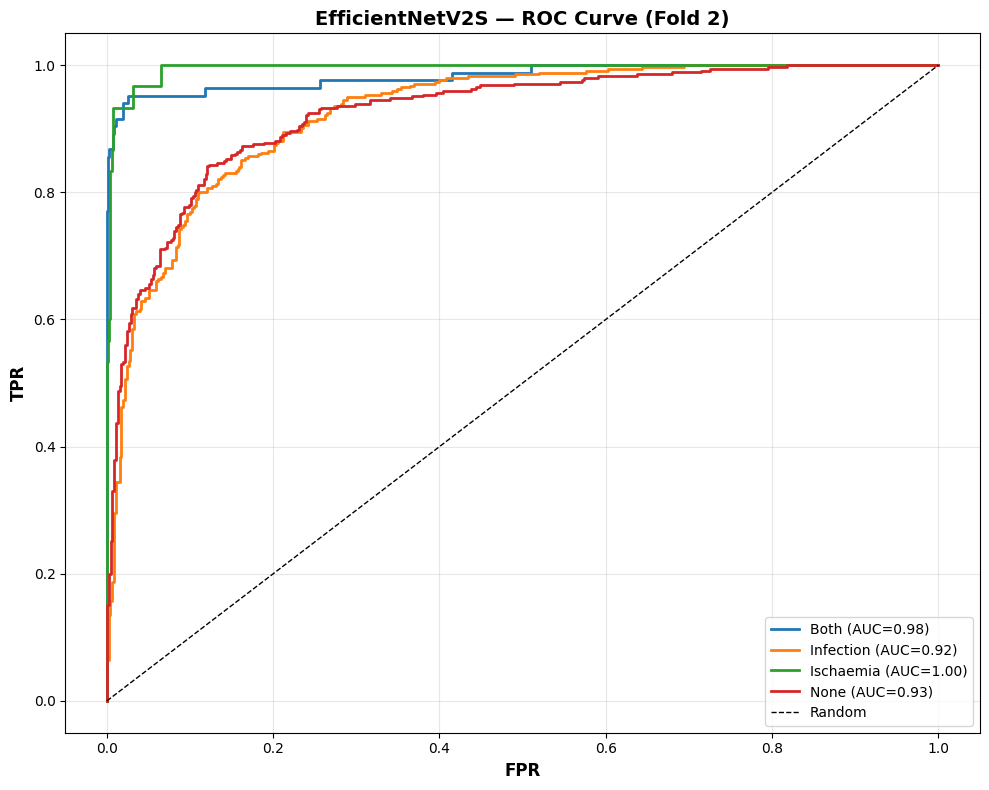

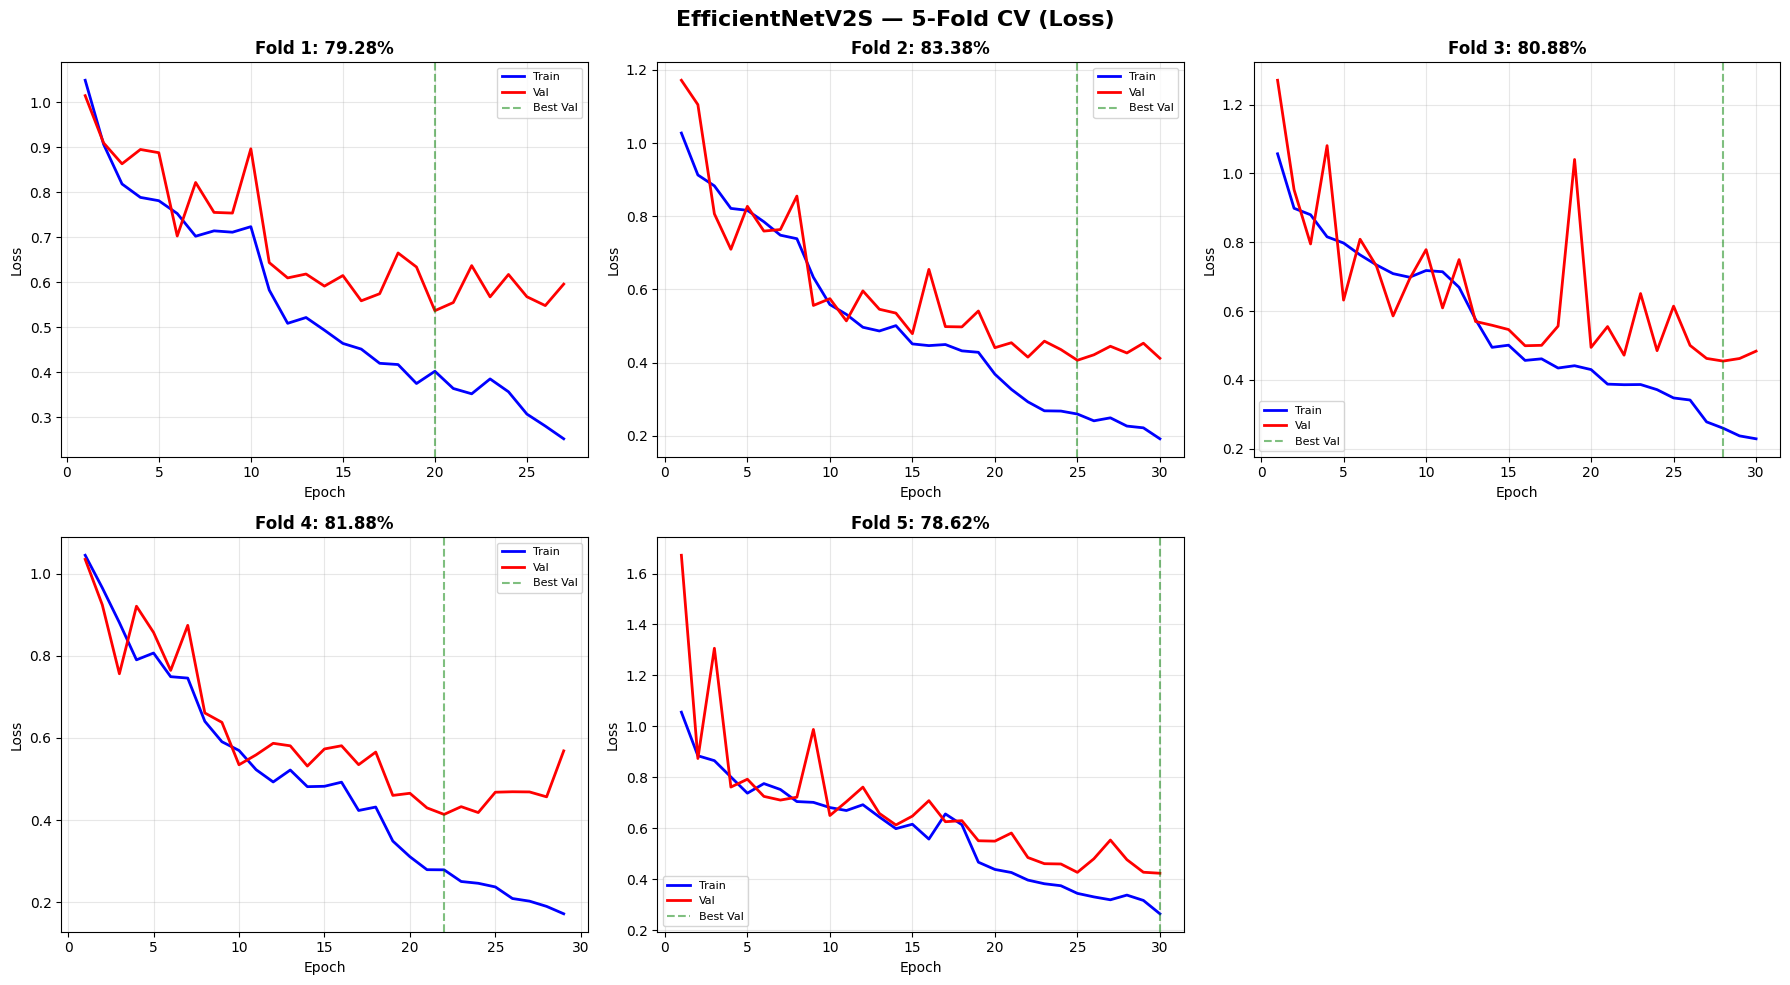

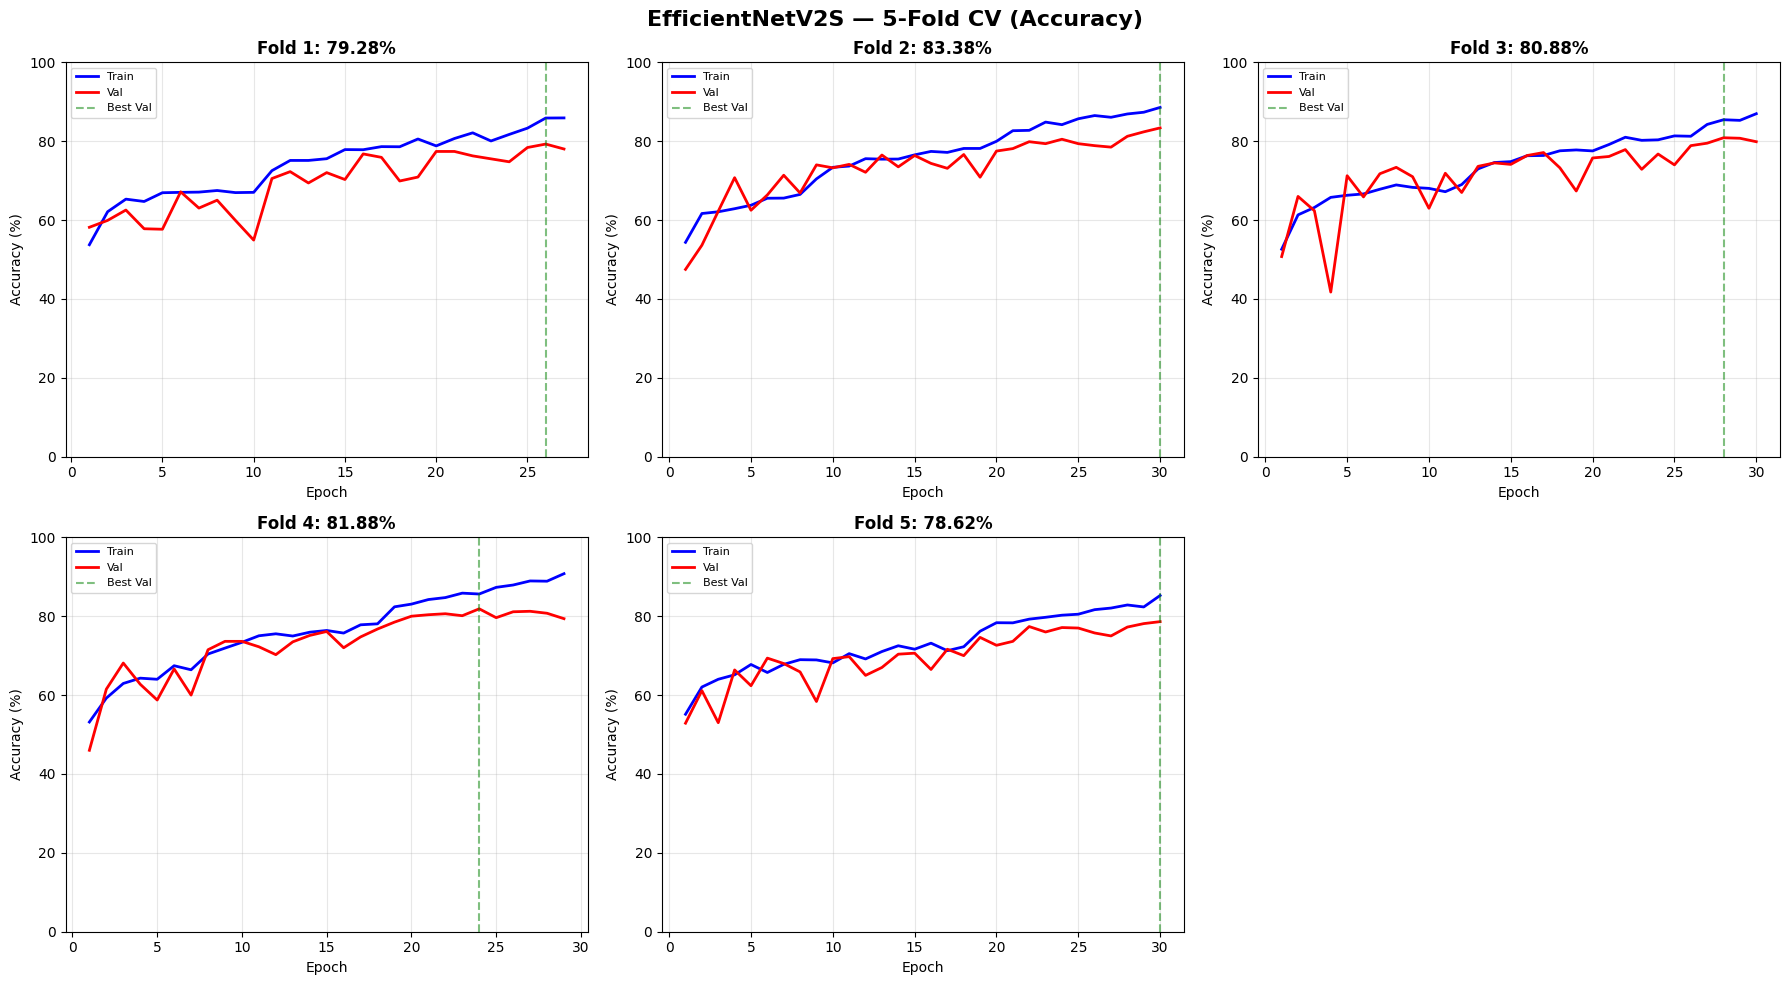

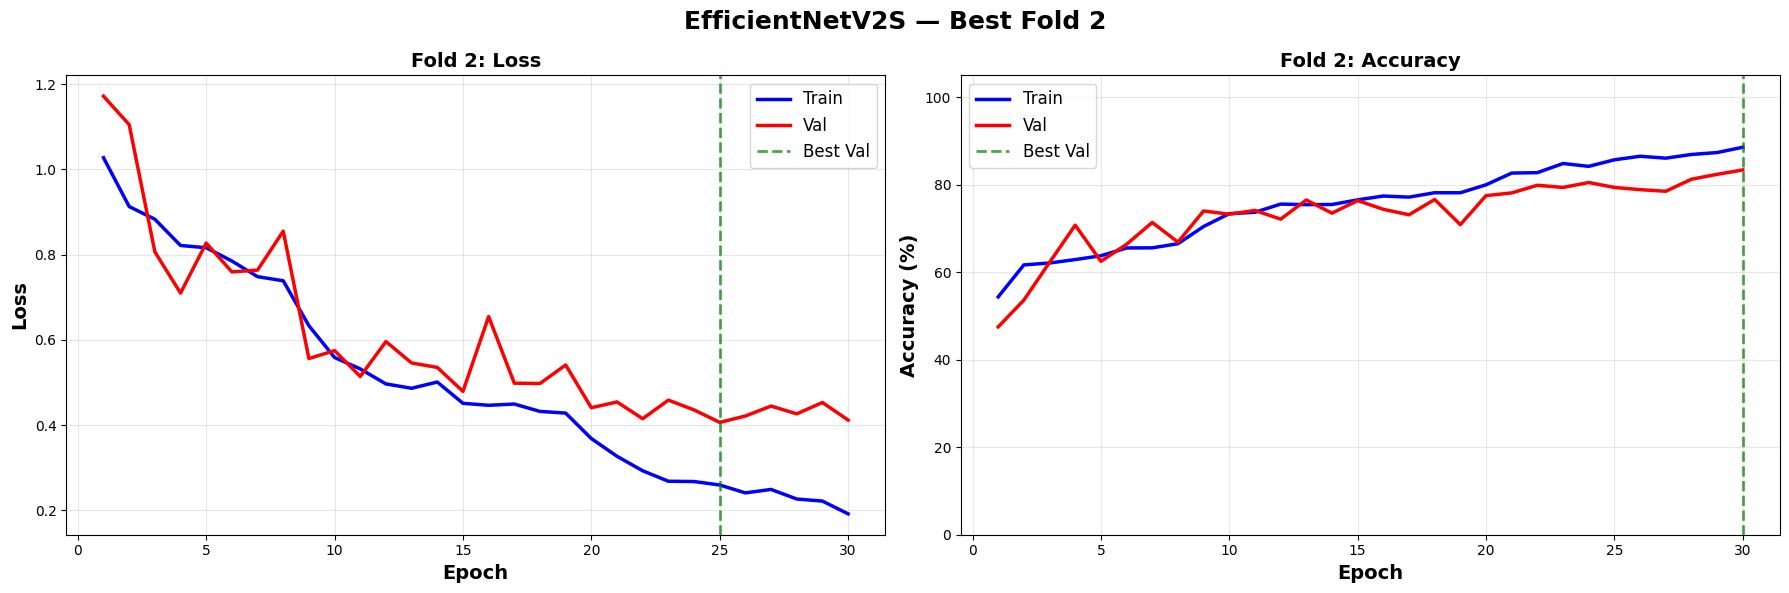


EfficientNetV2S CROSS-VALIDATION SUMMARY
Mean Accuracy: 80.81% ± 1.72%
Best Fold: 2 (83.38%)
Model loaded from: MEMORY
Average Epochs: 29.2
Results saved → results/efficientnetv2s/efficientnetv2s_cv_results.json


In [10]:

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
DPI = 300
PLOT_CONFIG = {
    'cm':      {'size': (10, 8), 'cmap': 'Blues'},
    'roc':     {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory: {os.path.abspath(model_results_dir)}")

# ══════════════════════════════════════════════════════════════════════════════
# GET BEST FOLD & LOAD BEST MODEL (from memory)
# ══════════════════════════════════════════════════════════════════════════════
best_fold_idx = int(np.argmax([r['best_val_acc'] for r in fold_results]))
best_fold_num = fold_results[best_fold_idx]['fold']

model = create_efficientnetv2s_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()
print(f"✓ Best fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"✓ Loaded best model from MEMORY")

# ══════════════════════════════════════════════════════════════════════════════
# GET PREDICTIONS (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFUSION MATRIX (BEST FOLD — RAW COUNTS)
# ══════════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. AGGREGATED CONFUSION MATRIX (ALL 5 FOLDS — from memory)
# ══════════════════════════════════════════════════════════════════════════════
print("\n⏳ Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx_f, val_idx_f) in enumerate(fold_splits, 1):
    val_dataset_fold = DFUDataset(X_all[val_idx_f], y_all[val_idx_f], transform=val_test_transform)
    val_loader_fold  = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    if fold_idx in fold_model_states:
        model_f = create_efficientnetv2s_model(num_classes=num_classes, pretrained=False)
        model_f.load_state_dict(fold_model_states[fold_idx])
        model_f = model_f.to(device).eval()
        
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inp, lbl in val_loader_fold:
                out = model_f(inp.to(device))
                fold_preds.append(torch.max(out, 1)[1].cpu().numpy())
                fold_labels.append(lbl.numpy())
        
        fp = np.concatenate(fold_preds)
        fl = np.concatenate(fold_labels)
        cm_aggregated += confusion_matrix(fl, fp, labels=range(num_classes))
        print(f"  ✓ Fold {fold_idx} processed")
        del model_f
    else:
        print(f"  ⚠ Fold {fold_idx} model state not in memory, skipping")

if cm_aggregated.sum() > 0:
    cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
    sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
    ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
    ax.set_title(f'{MODEL_NAME} — Aggregated Confusion Matrix (5-Fold CV)',
                 fontsize=FONT['title'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png',
                dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f"✓ Aggregated CM saved ({cm_aggregated.sum()} total predictions)")
else:
    print("⚠ No fold model states found in memory — skipping aggregated confusion matrix")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ROC CURVE (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'],
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — ROC Curve (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. ALL FOLDS — TRAINING HISTORY (LOSS)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Loss)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_loss']) + 1)
    
    ax.plot(ep, h['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(ep, h['val_loss'],   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_loss'].index(min(h['val_loss'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. ALL FOLDS — TRAINING HISTORY (ACCURACY)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Accuracy)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_acc']) + 1)
    
    train_pct = [a * 100 for a in h['train_acc']]
    val_pct   = [a * 100 for a in h['val_acc']]
    
    ax.plot(ep, train_pct, 'b-', label='Train', lw=2)
    ax.plot(ep, val_pct,   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_acc'].index(max(h['val_acc'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 6. BEST FOLD — DETAILED TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════
best_history = fold_results[best_fold_idx]['history']
epochs_range = range(1, len(best_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{MODEL_NAME} — Best Fold {best_fold_num}',
             fontsize=FONT['title']+4, fontweight='bold')

# Loss
ax1.plot(epochs_range, best_history['train_loss'], 'b-', label='Train', lw=2.5)
ax1.plot(epochs_range, best_history['val_loss'],   'r-', label='Val',   lw=2.5)
ax1.axvline(x=best_history['val_loss'].index(min(best_history['val_loss'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax1.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_title(f"Fold {best_fold_num}: Loss", fontsize=FONT['title'], fontweight='bold')
ax1.legend(fontsize=FONT['legend']+2)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in best_history['train_acc']], 'b-', label='Train', lw=2.5)
ax2.plot(epochs_range, [a*100 for a in best_history['val_acc']],   'r-', label='Val',   lw=2.5)
ax2.axvline(x=best_history['val_acc'].index(max(best_history['val_acc'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax2.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_title(f"Fold {best_fold_num}: Accuracy", fontsize=FONT['title'], fontweight='bold')
ax2.legend(fontsize=FONT['legend']+2)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SAVE CV RESULTS JSON
# ══════════════════════════════════════════════════════════════════════════════
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [
            {'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']),
             'stopped_epoch': int(r['stopped_epoch'])}
            for r in fold_results
        ]
    },
    'best_fold': {
        'fold_number': best_fold_num,
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'loaded_from': 'memory'
    }
}

with open(f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% \u00b1 {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Model loaded from: MEMORY")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"Results saved \u2192 {model_results_dir}/{MODEL_NAME.lower()}_cv_results.json")
print(f"{'='*60}")

## 8. Generate Comprehensive Metrics JSON

This cell generates a standalone comprehensive metrics JSON file from the in-memory model state.  
It includes **ROC curve data (FPR/TPR per class)** for cross-model ROC comparison.

In [11]:
import sys, os, json, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import EfficientNet_V2_S_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, auc,
                             matthews_corrcoef, cohen_kappa_score, log_loss)
from sklearn.preprocessing import label_binarize
from datetime import datetime
from PIL import Image

sys.path.append('../'); sys.path.append('./')
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing

print("="*80)
print("GENERATING COMPREHENSIVE METRICS")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================
MODEL_NAME     = 'EfficientNetV2S'
BATCH_SIZE     = 32
RESULTS_DIR    = 'results'
N_FOLDS        = 5
SEED           = 42

# ============================================================================
# 1/4  LOAD DATASET
# ============================================================================
print("\n[1/4] Loading dataset...")
loader      = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes     = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor       = DFUPreprocessing()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

kfold  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Loaded {len(X_all)} training samples")
print(f"✓ Classes: {classes}")

# ============================================================================
# MODEL DEFINITION
# ============================================================================
def create_efficientnetv2s_model(num_classes=4, pretrained=False):
    if pretrained:
        model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    else:
        model = models.efficientnet_v2_s(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

# ============================================================================
# 2/4  LOAD SAVED CV RESULTS
# ============================================================================
print("\n[2/4] Loading saved results...")
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
results_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json'

if not os.path.exists(results_json_path):
    raise FileNotFoundError(f"Results file not found: {results_json_path}")

with open(results_json_path, 'r') as f:
    saved_results = json.load(f)

fold_results_sec9 = []
for fd in saved_results['cv_results']['fold_results']:
    fold_results_sec9.append({
        'fold':         fd['fold'],
        'best_val_acc': fd['best_val_acc'],
        'final_val_acc': fd.get('final_val_acc', fd['best_val_acc']),
        'stopped_epoch': fd['stopped_epoch']
    })

avg_acc    = saved_results['cv_results']['val_accuracy']['mean']
std_acc    = saved_results['cv_results']['val_accuracy']['std']
avg_epochs = saved_results['cv_results']['avg_epochs']

print(f"✓ Loaded CV results: {avg_acc*100:.2f}% \u00b1 {std_acc*100:.2f}%")

# ============================================================================
# 3/4  LOAD BEST MODEL (from memory) & EVALUATE ON VALIDATION SET
# ============================================================================
print("\n[3/4] Loading best model & evaluating on validation set...")

best_fold_idx_s9 = int(np.argmax([r['best_val_acc'] for r in fold_results_sec9]))
best_fold_num_s9 = fold_results_sec9[best_fold_idx_s9]['fold']

model = create_efficientnetv2s_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(best_model_state)
model = model.to(device).eval()
print(f"✓ Loaded best model from MEMORY (fold {best_fold_num_s9})")

fold_splits           = list(kfold.split(X_all, y_all))
train_idx, val_idx    = fold_splits[best_fold_idx_s9]
val_dataset           = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader            = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs   = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

print(f"✓ Evaluated {len(true_labels)} validation samples")

# ============================================================================
# 4/4  CALCULATE COMPREHENSIVE METRICS
# ============================================================================
print("\n[4/4] Calculating comprehensive metrics...")

y_true_bin = label_binarize(true_labels, classes=range(num_classes))

# ══════════════════════════════════════════════════════════════════════════════
# HELPER: compute full metrics + ROC for a given set of predictions
# ══════════════════════════════════════════════════════════════════════════════
def compute_all_metrics(y_true, y_pred, y_proba, y_true_bin, class_names, n_classes):
    """Return (per_class_metrics, roc_curves_data, summary_dict)."""
    pcm = {}
    roc_data = {}

    for i, cname in enumerate(class_names):
        mask  = (y_true == i)
        cpred = (y_pred == i)
        tp = int(np.sum(cpred & mask))
        fp = int(np.sum(cpred & ~mask))
        fn = int(np.sum(~cpred & mask))
        tn = int(np.sum(~cpred & ~mask))

        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1v  = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        spec = tn/(tn+fp) if (tn+fp) else 0.0

        try:    auc_s = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except: auc_s = 0.0

        fpr, tpr, thresh = roc_curve(y_true_bin[:, i], y_proba[:, i])

        pcm[cname] = {
            'precision': float(prec), 'recall': float(rec),
            'f1_score': float(f1v), 'specificity': float(spec),
            'sensitivity': float(rec), 'auc': float(auc_s),
            'support': int(np.sum(mask)),
            'true_positives': tp, 'false_positives': fp,
            'false_negatives': fn, 'true_negatives': tn
        }
        roc_data[cname] = {
            'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
            'thresholds': thresh.tolist(), 'auc': float(auc_s)
        }

    # Aggregate AUCs
    try:    macro_auc    = roc_auc_score(y_true_bin, y_proba, average='macro',    multi_class='ovr')
    except: macro_auc    = 0.0
    try:    micro_auc    = roc_auc_score(y_true_bin, y_proba, average='micro',    multi_class='ovr')
    except: micro_auc    = 0.0
    try:    weighted_auc = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')
    except: weighted_auc = 0.0

    # Micro-average ROC curve
    fpr_mi, tpr_mi, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_data['micro_average'] = {
        'fpr': fpr_mi.tolist(), 'tpr': tpr_mi.tolist(), 'auc': float(micro_auc)
    }

    # Macro-average ROC curve (interpolated)
    all_fpr = np.unique(np.concatenate([np.array(roc_data[c]['fpr']) for c in class_names]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in class_names:
        mean_tpr += np.interp(all_fpr, np.array(roc_data[c]['fpr']), np.array(roc_data[c]['tpr']))
    mean_tpr /= n_classes
    roc_data['macro_average'] = {
        'fpr': all_fpr.tolist(), 'tpr': mean_tpr.tolist(), 'auc': float(macro_auc)
    }

    # Summary scalars
    acc  = float(np.sum(y_pred == y_true) / len(y_true))
    try:    mcc_v   = float(matthews_corrcoef(y_true, y_pred))
    except: mcc_v   = 0.0
    try:    kappa_v = float(cohen_kappa_score(y_true, y_pred))
    except: kappa_v = 0.0
    try:    ll_v    = float(log_loss(y_true, y_proba))
    except: ll_v    = 0.0

    summary = {
        'accuracy':          acc,
        'macro_precision':   float(np.mean([m['precision']   for m in pcm.values()])),
        'macro_recall':      float(np.mean([m['recall']      for m in pcm.values()])),
        'macro_f1':          float(np.mean([m['f1_score']    for m in pcm.values()])),
        'macro_specificity': float(np.mean([m['specificity'] for m in pcm.values()])),
        'macro_sensitivity': float(np.mean([m['sensitivity'] for m in pcm.values()])),
        'macro_auc':         float(macro_auc),
        'micro_auc':         float(micro_auc),
        'weighted_auc':      float(weighted_auc),
        'matthews_corrcoef': mcc_v,
        'cohen_kappa':       kappa_v,
        'log_loss':          ll_v,
        'total_samples':        len(y_true),
        'correct_predictions':  int(np.sum(y_pred == y_true)),
        'incorrect_predictions': int(np.sum(y_pred != y_true)),
    }
    return pcm, roc_data, summary

# ── Compute for VALIDATION set ────────────────────────────────────────────────────
val_pcm, val_roc, val_summary = compute_all_metrics(
    true_labels, predictions, y_pred_proba, y_true_bin, classes, num_classes)

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm_val = confusion_matrix(true_labels, predictions)

# ============================================================================
# BUILD TOP-LEVEL  model_level_roc  (the one-stop section for comparison)
# ============================================================================
def _build_model_roc_block(roc_data, summary, pcm, class_names):
    """Flatten roc data into a model-level comparison-friendly dict."""
    block = {
        'macro_auc':    summary['macro_auc'],
        'micro_auc':    summary['micro_auc'],
        'weighted_auc': summary['weighted_auc'],
        'per_class_auc': {c: pcm[c]['auc'] for c in class_names},
        'per_class': {
            c: {'fpr': roc_data[c]['fpr'],
                'tpr': roc_data[c]['tpr'],
                'auc': roc_data[c]['auc']}
            for c in class_names
        },
        'micro_average': roc_data['micro_average'],
        'macro_average': roc_data['macro_average'],
    }
    return block

model_level_roc = {
    'model_name':   MODEL_NAME,
    'architecture': 'EfficientNetV2-S',
    'num_classes':  num_classes,
    'class_names':  classes,
    'validation':   _build_model_roc_block(val_roc, val_summary, val_pcm, classes),
}

# ============================================================================
# COMPILE COMPREHENSIVE RESULTS
# ============================================================================
comprehensive_results = {
    'model_info': {
        'model_name':        MODEL_NAME,
        'architecture':      'EfficientNetV2-S',
        'pretrained':        True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size':        [3, 224, 224],
        'num_classes':       num_classes,
        'class_names':       classes
    },
    'training_config': {
        'optimizer':                'Adam',
        'learning_rate_initial':    1e-3,
        'weight_decay':             1e-4,
        'learning_rate_schedule':   'ReduceLROnPlateau',
        'lr_plateau_factor':        0.3,
        'lr_plateau_patience':      3,
        'lr_plateau_min_lr':        1e-7,
        'batch_size':               BATCH_SIZE,
        'num_epochs':               30,
        'early_stopping_patience':  7,
        'loss_function':            'CrossEntropyLoss',
        'class_weights':            'balanced (sklearn)',
        'augmentation': {
            'horizontal_flip': 0.5,
            'vertical_flip':   0.5,
            'rotation':        20,
            'zoom_range':      [0.8, 1.2],
            'brightness':      0.1,
            'contrast':        0.1
        }
    },
    'dataset_info': {
        'dataset_name':      'DFU Dataset (4 Classes)',
        'source':            'Roboflow (dfu-o28ut / dfu-kew1f-gzodp v1)',
        'total_samples':     len(X_all),
        'training_samples':  len(X_all),
        'num_folds':         N_FOLDS,
        'stratified':        True,
        'random_state':      SEED,
        'class_distribution': {
            c: int(np.sum(y_all == i)) for i, c in enumerate(classes)
        }
    },
    'cross_validation': {
        'num_folds':       N_FOLDS,
        'mean_accuracy':   float(avg_acc),
        'std_accuracy':    float(std_acc),
        'min_accuracy':    float(min(r['best_val_acc'] for r in fold_results_sec9)),
        'max_accuracy':    float(max(r['best_val_acc'] for r in fold_results_sec9)),
        'average_epochs':  float(avg_epochs),
        'best_fold': {
            'fold_number':   int(best_fold_num_s9),
            'accuracy':      float(fold_results_sec9[best_fold_idx_s9]['best_val_acc']),
            'stopped_epoch': int(fold_results_sec9[best_fold_idx_s9]['stopped_epoch'])
        },
        'individual_folds': [
            {
                'fold':               r['fold'],
                'best_val_accuracy':  float(r['best_val_acc']),
                'final_val_accuracy': float(r['final_val_acc']),
                'stopped_epoch':      int(r['stopped_epoch'])
            }
            for r in fold_results_sec9
        ]
    },

    # ════════════════════════════════════════════════════════════════════
    # TOP-LEVEL MODEL ROC — for quick cross-model comparison
    # ════════════════════════════════════════════════════════════════════
    'model_level_roc': model_level_roc,

    # ════════════════════════════════════════════════════════════════════
    # VALIDATION RESULTS (detailed)
    # ════════════════════════════════════════════════════════════════════
    'validation_results': {
        'best_fold_number':      int(best_fold_num_s9),
        **val_summary,
        'per_class_metrics':     val_pcm,
        'confusion_matrix': {
            'matrix':     cm_val.tolist(),
            'normalized': (cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels':     classes
        },
        'roc_curves': val_roc
    },

    'metadata': {
        'timestamp':            datetime.now().isoformat(),
        'framework':            'PyTorch',
        'pytorch_version':      torch.__version__,
        'cuda_available':       torch.cuda.is_available(),
        'experiment_name':      'efficientnetv2s_5fold_cv',
        'model_loaded_from':    'memory',
        'generated_standalone': True
    }
}

# ============================================================================
# SAVE
# ============================================================================
os.makedirs(model_results_dir, exist_ok=True)
comprehensive_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_comprehensive_metrics.json'

with open(comprehensive_json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

# ============================================================================
# DISPLAY SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)

print(f"\nMODEL: {MODEL_NAME}")
print(f"Model loaded from: MEMORY")

print(f"\nCROSS-VALIDATION ({N_FOLDS}-Fold):")
print(f"  Mean Accuracy : {avg_acc*100:.2f}% \u00b1 {std_acc*100:.2f}%")
print(f"  Best Fold     : {best_fold_num_s9} ({fold_results_sec9[best_fold_idx_s9]['best_val_acc']*100:.2f}%)")
print(f"  Average Epochs: {avg_epochs:.1f}")

print(f"\nVALIDATION SET (Best Fold {best_fold_num_s9}):")
print(f"  Accuracy     : {val_summary['accuracy']*100:.2f}%")
print(f"  Macro AUC    : {val_summary['macro_auc']:.4f}")
print(f"  Micro AUC    : {val_summary['micro_auc']:.4f}")
print(f"  Weighted AUC : {val_summary['weighted_auc']:.4f}")
print(f"  MCC          : {val_summary['matthews_corrcoef']:.4f}")
print(f"  Cohen Kappa  : {val_summary['cohen_kappa']:.4f}")
print(f"  Log Loss     : {val_summary['log_loss']:.4f}")

print(f"\nPER-CLASS METRICS (Validation):")
for cname, m in val_pcm.items():
    print(f"\n  {cname} (n={m['support']}):")
    print(f"    Precision   : {m['precision']:.4f}")
    print(f"    Recall      : {m['recall']:.4f}")
    print(f"    F1-Score    : {m['f1_score']:.4f}")
    print(f"    Specificity : {m['specificity']:.4f}")
    print(f"    AUC         : {m['auc']:.4f}")

print(f"\n{'='*80}")
print("MODEL-LEVEL ROC SUMMARY (for cross-model comparison):")
print(f"{'='*80}")
print(f"  Validation \u2014 Macro AUC: {model_level_roc['validation']['macro_auc']:.4f}  "
      f"Micro AUC: {model_level_roc['validation']['micro_auc']:.4f}  "
      f"Weighted AUC: {model_level_roc['validation']['weighted_auc']:.4f}")
print(f"  Per-class AUC (Val) : { {c: f'{v:.4f}' for c,v in model_level_roc['validation']['per_class_auc'].items()} }")
print(f"  ROC curve points included: per_class + micro_average + macro_average (FPR/TPR arrays)")

print(f"\n{'='*80}")
print(f"✓ Saved comprehensive metrics to:")
print(f"  {os.path.abspath(comprehensive_json_path)}")
file_size = os.path.getsize(comprehensive_json_path) / 1024
print(f"  File size: {file_size:.2f} KB")
print(f"\n  JSON structure for cross-model comparison:")
print(f"    json['model_level_roc']['validation']['macro_auc']       \u2192 single number")
print(f"    json['model_level_roc']['validation']['per_class_auc']   \u2192 dict of class\u2192AUC")
print(f"    json['model_level_roc']['validation']['per_class'][cls]  \u2192 {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['micro_average']   \u2192 {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['macro_average']   \u2192 {{'fpr':[], 'tpr':[], 'auc':float}}")
print("="*80)
print("COMPLETE ✓")
print("="*80)

GENERATING COMPREHENSIVE METRICS

[1/4] Loading dataset...
[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
✓ Loaded 4001 training samples
✓ Classes: ['Both', 'Infection', 'Ischaemia', 'None']

[2/4] Loading saved results...
✓ Loaded CV results: 80.81% ± 1.72%

[3/4] Loading best model & evaluating on validation set...
✓ Loaded best model from MEMORY (fold 2)
✓ Evaluated 800 validation samples

[4/4] Calculating comprehensive metrics...

COMPREHENSIVE METRICS SUMMARY

MODEL: EfficientNetV2S
Model loaded from: MEMORY

CROSS-VALIDATION (5-Fold):
  Mean Accuracy : 80.81% ± 1.72%
  Best Fold     : 2 (83.

In [12]:
# ── Zip EfficientNetV2S results for download ─────────────────────────────
import shutil

# Only zip the model-specific results folder generated by this notebook
src_path = os.path.join(os.getcwd(), RESULTS_DIR, MODEL_NAME.lower())
zip_output = f'/kaggle/working/{MODEL_NAME.lower()}_results'

shutil.make_archive(zip_output, 'zip', src_path)
print(f"✓ Zipped → {zip_output}.zip")
print(f"  Size: {os.path.getsize(zip_output + '.zip') / (1024*1024):.2f} MB")

from IPython.display import FileLink
FileLink(f'{zip_output}.zip')

✓ Zipped → /kaggle/working/efficientnetv2s_results.zip
  Size: 1.24 MB


/kaggle/working/efficientnetv2s_results.zip